In [41]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

# Topic 1

HEW6

## 1) (Score: 30 %) For the following choice for the basis functions ϕ(x) = {ϕ0(x), ϕ1(x), ϕ2(x)} = {1, x, x2} leading to the regression model ˆy(x, w) = w0 + w1x + w2x2, setup and write the design matrix Φ and use it to write the normal equations for the least squares problem.

The design matrix will be

$$
\Phi =
\begin{bmatrix}
1 & 0.5 & 0.5^{2} \\
1 & 2.5 & 2.5^{2} \\
1 & 4.5 & 4.5^{2}
\end{bmatrix}
=
\begin{bmatrix}
1 & 0.5 & 0.25 \\
1 & 2.5 & 6.25 \\
1 & 4.5 & 20.25
\end{bmatrix}
$$

Which results in the normal equation
$$
W_{ML} = 
\left(
\begin{bmatrix}
1 & 0.5 & 0.25 \\
1 & 2.5 & 6.25 \\
1 & 4.5 & 20.25
\end{bmatrix}^T
\begin{bmatrix}
1 & 0.5 & 0.25 \\
1 & 2.5 & 6.25 \\
1 & 4.5 & 20.25
\end{bmatrix}
\right)^{-1}
\begin{bmatrix}
1 & 0.5 & 0.25 \\
1 & 2.5 & 6.25 \\
1 & 4.5 & 20.25
\end{bmatrix}^T
\begin{bmatrix}
0.4 \\
0.9 \\
0.25
\end{bmatrix}^T
$$

## 2) (Score: 15 %) Find the solution of the normal equations, obtained in the previous step, to calculate the weights (w0, w1, and w2) of the regression model.

In [61]:
x = np.array([0.5, 2.5, 4.5])
y = np.array([[0.4],
              [0.9],
              [0.25]])
Phi = np.vander(x, increasing=True)
W_ML = np.linalg.inv(Phi.T @ Phi) @ Phi.T @ y
W_ML

array([[ 0.0953125],
       [ 0.68125  ],
       [-0.14375  ]])

## 3) (Score: 25 %) Using the regression model obtained above, predict the values yi for the training points {x1 = 0.5, x2 = 2.5, x3 = 4.5} as well as the test points x4 = 2, and for x5 = 3.5. Plot the corresponding points (xi, yi) in the 2D space in Fig. 1. Roughly draw the regression curve by joining those five points in Fig. 1.

In [69]:
def apply_weigths(data, weigths):
    result = 0
    for i in range(len(weigths)):
        result += weigths[i] * data**i
    return result

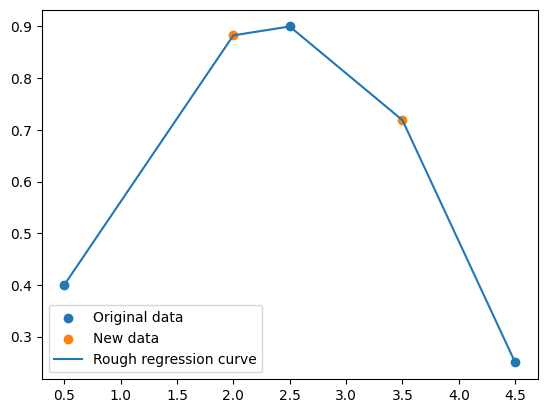

In [74]:
plt.scatter(x, apply_weigths(x, W_ML), label="Original data")

x_new = np.array([2, 3.5])
plt.scatter(x_new, apply_weigths(x_new, W_ML), label="New data")

all_data = np.sort(np.hstack((x,x_new)))
plt.plot(all_data, apply_weigths(all_data, W_ML), label="Rough regression curve")
plt.legend()

## 4) (Score: 30 %) Consider Fig. 2 (right-sided figure above) where two more data points (red-squares) have been added to the original data set from Fig. 1 (blue-circles). Assume that the original model ˆy(x, w) = w0 + w1x + w2x2 (from part 1 of this topic) when trained on this new data does not produce acceptably accurate results. What changes would you make to the regression model to make it work better on this new data, and why? Note that you are not required to write or solve the normal equations in this case.

It seems like the data now contains two peaks instead of only one. This cannot be modelled with a second degree polynomial. The model could be changed to either a third degree polynomial or sinusoidal regression model which could accomodate for the new peak.

# Topic 2

HEW7


slide 362

## 1) (Score: 25 %) Apply the K-nearest neighbour classification algorithm to classify the two test data points to either C1 or C2. Use the value of the parameter K = 1.

In [103]:
X = np.array([  [2, 3, 4, 6, 7, 8],
                [3, 4, 2, 6, 5, 7]])
T = np.array([  [5, 6],
                [4, 4.5]])
t = np.array([0, 0, 0, 1, 1, 1])

def dist(a, b):
    return np.linalg.norm(a - b)

for xt in T.T:
    xtvec = xt[:,np.newaxis]
    dist_list = []
    for xn in X.T:
        xnvec = xn[:,np.newaxis]
        dist_list.append(dist(xtvec, xnvec))
    xtlabel = t[np.argmin(dist_list)]
    print(f"{xtvec} is classified as C_{xtlabel+1}\n")


[[5.]
 [4.]] is classified as C_1

[[6. ]
 [4.5]] is classified as C_2



## 2) (Score: 25 %) Apply the nearest-centeroid-based classification algorithm to classify the two test data points to either C1 or C2. 

In [104]:
centroids = np.hstack(( np.mean(X[:, t == 0], axis=1)[:, np.newaxis],
                        np.mean(X[:, t == 1], axis=1)[:, np.newaxis]))

for x in T.T:
    xvec = x[:,np.newaxis]
    if dist(centroids[:, 0], xvec) <= dist(centroids[:, 1], xvec):
        print(f"{xvec} is classified as C_1\n")
    else:
        print(f"{xvec} is classified as C_2\n")

[[5.]
 [4.]] is classified as C_1

[[6. ]
 [4.5]] is classified as C_2



## 3) (Score: 25 %) Calculate the projection vector w ∈ R2 using the training data points (blue-squares and red circles in Fig. 3).

In [105]:
def class_means(X, t):
    classes = np.unique(t)
    ms = list(np.zeros(len(classes)))
    Ns = list(np.zeros(len(classes)))
    N = len(X)
    for n in range(N):
        Ns[t[n]-1] += 1
        ms[t[n]-1] += X[n]
    
    return_array = []
    for m, n in zip(ms, Ns):
        return_array.append(m/n)
    return return_array

m1, m2 = class_means(X.T, t)
print(f"Mean for class 1: {m1}")
print(f"Mean for class 2: {m2}")

def scatter_matrix(X, t):
    m1, m2 = class_means(X, t)
    S_B = np.outer((m2 - m1), (m2 - m1))

    S_W = 0
    N = len(X)
    for n in range(N):
        xn = X[n]
        if t[n] == 1:
            S_W += np.outer((xn - m1), (xn - m1))
        else:
            S_W += np.outer((xn - m2), (xn - m2))
    
    return S_B, S_W

_, S_W = scatter_matrix(X.T, t)
S_W
print(f"S_W = \n{S_W}")

def projection_vector(S_W, m1, m2):
    S_W_i = np.linalg.pinv(S_W)
    w = S_W_i @ (m2 - m1)
    return w / np.linalg.norm(w)

w = projection_vector(S_W, m1, m2)
print(f"w = \n{w}")

Mean for class 1: [7. 6.]
Mean for class 2: [3. 3.]
S_W = 
[[4. 0.]
 [0. 4.]]
w = 
[-0.8 -0.6]


## 4) Score: 25 %) Project the training data points to 1-dimensional space R using the projection vector w, yielding {yk}N k=1. Choose an empirical threshold value y0 that maximizes the margin between the two classes on the projected training set. Subsequently, using that threshold value, classify the two test data points (green triangles in Fig. 3) to either C1 or C2.

In [123]:
Y = w.T @ X
Y_C1 = Y[t==0]
Y_C2 = Y[t==1]
y_0 = (np.min(Y_C2) - np.max(Y_C1)) / 2 + np.max(Y_C1)
print("The empirical threshold is chosen to be", y_0)

The empirical threshold is chosen to be -7.0


In [132]:
for T_i in T.T:
    Y_T = T_i[:, np.newaxis]
    if w.T @ Y_T > y_0:
        print(Y_T, "is part of class C1")
    else:
        print(Y_T, "is part of class C2")


[[5.]
 [4.]] is part of class C1
[[6. ]
 [4.5]] is part of class C2


# Topic 3

HEW11

slide 462

## 1) (Score: 30%) Given the first data point x1 = [0.6, −0.3]T from the training set, what is the output value of the neural network? Show your intermediate calculations.

In [133]:
W_1 = np.array([[0.2, -0.8, 0.6],
                [0.7, -1.0, 0.3],
                [-0.5, -0.3, -0.4]])
W_2 = np.array([[0.7],
                [0.2],
                [-0.1],
                [-0.4]])
weigths = [W_1, W_2]

x = np.array([[0.6, -0.3]]).T

# slide 450
def neuron_transformation(x, W, h):
    xbias = np.vstack(([1.0], x))
    a = W.T @ xbias
    print("a =\n", a)
    z = h(a)
    print("z =\n", z)
    return a, z

# slide 452
def sigmoid(a):
    return 1 / (1 + np.exp(-a))

def identity(a):
    return a

def forward(x, weigths, h, h_output=None):
    activations = []
    outputs = []
    z = x
    num_layers = len(weigths)

    for i, W in enumerate(weigths):
        if i == num_layers-1 and h_output:
            h = h_output
        print(f"-- Layer {i+1} calculation steps --")
        a, z = neuron_transformation(z, W, h)
        activations.append(a)
        outputs.append(z)
        print()
    return outputs[-1], activations, outputs

y1, activations, outputs = forward(x, weigths, sigmoid, identity)
print("y =", y1.item())

-- Layer 1 calculation steps --
a =
 [[ 0.77]
 [-1.31]
 [ 0.9 ]]
z =
 [[0.68352089]
 [0.21248684]
 [0.7109495 ]]

-- Layer 2 calculation steps --
a =
 [[0.53107569]]
z =
 [[0.53107569]]

y = 0.5310756932850076


## 2) (Score: 20%) Assuming the output of the network is y1 = 0.531 given the data point x1. What is the sum-of-squares error E(t1, y1), if the corresponding target is t1 = −0.5.

In [138]:
def sum_of_squares_error(t, y):
    return 1/2 * np.sum(y - t)**2

t1 = np.array([[-0.5]])
print("The sum of squares error is E[t_1, y_1] =", sum_of_squares_error(t1, y1))

The sum of squares error is E[t_1, y_1] = 0.5315585426415795


## 3) (Score: 30%) Given the data point x1 and the target t1, use backpropagation to calculate the following partial derivatives of the error: ∂E(t1,y1) ∂a2,1 , ∂E(t1,y1) ∂w(2) 2,1 , ∂E(t1,y1) ∂a1,2 and ∂E(t1,y1) ∂w(1) 1,2 . Show your intermediate calculations.

In [46]:
# slide 452
def sigmoid_derivative(a):
    z = sigmoid(a)
    return z * (1 - z)

def compute_all_gradients(x, t, weights, activations, outputs, y, h_derivative):
    num_layers = len(weights)
    gradients = [None] * num_layers
    deltas = [None] * num_layers

    #print(f"-- Layer {num_layers} calculation steps --")
    deltas[-1] = y - t
    

    for k in range(num_layers - 2, -1, -1):
        W_no_bias = weights[k + 1][1:, :]
        deltas[k] = (W_no_bias @ deltas[k + 1]) * h_derivative(activations[k])
    for k in range(num_layers):
        if k == 0:
            z_prev = np.vstack(([1.0], x))
        else:
            z_prev = np.vstack(([1.0], outputs[k - 1]))

        gradients[k] = z_prev @ deltas[k].T
    return gradients, deltas

gradients, deltas = compute_all_gradients(x, t1, weigths, activations, outputs, y1, sigmoid_derivative)

print(f"\n∂E/∂a_2,1 = {deltas[1][0].item()}")
print(f"\n∂E/∂w^(2)_2,1 = {gradients[1][2, 0]}")
print(f"\n∂E/∂a_1,2 = {deltas[0][1].item()}")
print(f"\n∂E/∂w^(1)_1,2 = {gradients[0][1, 1]}")


∂E/∂a_2,1 = 1.0310756932850076

∂E/∂w^(2)_2,1 = 0.21909002011759046

∂E/∂a_1,2 = -0.017253627316406006

∂E/∂w^(1)_1,2 = -0.010352176389843603


## 4)

No, because it is not trained on data in that domain, so it would have no way of being able to predict anything there.

# Topic 4

## 1) (Score: 35%) Using your conceptual understanding of the SVM (without solving the actual SVM optimization problem), indicate which training data points may reasonably act as support vectors in Fig. 5 and also draw the possible decision function/boundary and margins of (linear) SVM. Explain your reasoning. Please use Fig. 5 for identifying the support vectors and drawing the decision boundary and margins.

Since training has been done with no slack variables, there will be no datapoints going past the margins (green). The support vectors are highlighted with orange.

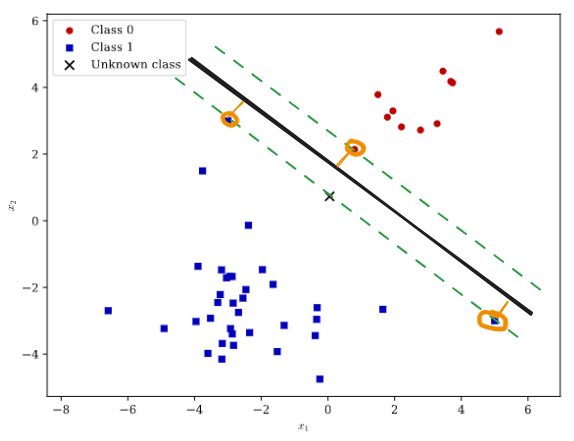

## 2) Score: 25%) Given a test data point indicated by the symbol (×) in Fig. 5, use the SVM decision boundary from the previous question to assign this data point to either class C0 or C1.

The test data point will be assigned to class C1.

## 3) (Score: 40%) Consider the two cases shown in Fig. 6 and Fig. 7, where some new data points have been added to the training set (shown by green triangles ▶ added to C0, and green diamonds ♦ added to C1, respectively). Considering that the linear SVM is again trained for binary classification in both cases, specify for each case whether the original decision boundary obtained earlier (in part 1 of the problem) will change or not. Briefly explain your reasoning. If the decision boundary changes, roughly draw the new decision boundary and margins and also identify the support vectors in Fig. 6 or Fig. 7 or both.

Figure 6 would change since it adds points that cross the previous margin/decision boundary. Assuming there still is no slack variables, it would look like this. Figure 7 however would not change since the added data point are far away from the decision boundary. If the added points would have had slack variables the decision boundary wouldnt necessarily change. With the old decision boundary the new point for C0 would simply have a slack variable $\xi > 1$.

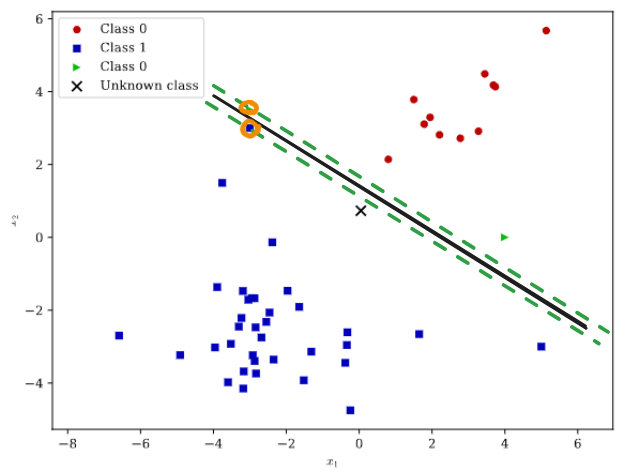